# VISTA vs Baseline LLaVA on FracAtlas

This notebook evaluates **three** setups on `FracAtlas`: **baseline** `llava-1.5`, **VISTA** (VSV + SLA with a null-image negative), and **Vista focused** (same VSV + SLA, but the VSV negative uses a **matched non-fracture** X-ray for the inferred body region plus the same text prompt as the positive forward).

It performs:
1. Dependency setup.
2. Caption generation for selected X-ray images.
3. Fracture vs non-fracture classification.
4. Accuracy and F1 score computation against ground truth.
5. Bounding-box prompting for fracture localization.
6. Localization analysis using overlap with ground-truth boxes, with `>= 50%` overlap tagged as correct.

> Note: In the original VISTA codebase, the logit intervention is named `SLA` (`--logits-aug`).
> In this notebook, the `SLV` request is mapped to VISTA's `SLA` option.

In [1]:


%pip install -q pandas scikit-learn scikit-image matplotlib tqdm pillow lxml nltk scipy opencv-python decord webdataset wandb visual-genome
%pip install -q transformers==4.37.0 "tokenizers>=0.15,<0.16" sentencepiece accelerate einops timm peft==0.13.0 omegaconf iopath PyYAML

print("Done cell 1. GPU: restart kernel → run cell 1 → cell 2.")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Done cell 1. GPU: restart kernel → run cell 1 → cell 2.


In [2]:
# 2) Imports — CUDA only (raises if no GPU / CPU torch)

import os
import re
import json
import sys
import random
import argparse
import subprocess
import xml.etree.ElementTree as ET
from pathlib import Path
from dataclasses import dataclass, asdict, replace
from typing import List, Dict, Any, Optional, Tuple

for _dp in Path(os.environ.get("VISTA_TORCH_PREFIX", "/workspace/torch-cuda")).rglob("dist-packages"):
    if _dp.is_dir() and (_dp / "torch").is_dir():
        _p = str(_dp)
        if _p not in sys.path:
            sys.path.insert(0, _p)
        break

_isolate = os.environ.get("VISTA_ISOLATE_GPU", "").strip().lower() in ("1", "true", "yes")
_phys = int(os.environ.get("VISTA_CUDA_DEVICE", "0"))
if _isolate and "CUDA_VISIBLE_DEVICES" not in os.environ:
    os.environ["CUDA_VISIBLE_DEVICES"] = str(_phys)
    CUDA_DEVICE_ID = 0
else:
    CUDA_DEVICE_ID = _phys


def _pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])


def _need(mods):
    miss = []
    for mod, pkg in mods:
        try:
            __import__(mod)
        except Exception:
            miss.append(pkg)
    if miss:
        _pip(*miss)


_need(
    [
        ("numpy", "numpy"),
        ("pandas", "pandas"),
        ("PIL", "pillow"),
        ("tqdm", "tqdm"),
        ("sklearn", "scikit-learn"),
    ]
)
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report


def _torch_cuda_index():
    t = os.environ.get("VISTA_PYTORCH_CUDA", "auto").strip().lower()
    if t == "cpu":
        raise RuntimeError("CUDA required: do not set VISTA_PYTORCH_CUDA=cpu.")
    if t == "auto":
        t = "cu128"
    return f"https://download.pytorch.org/whl/{t}"


def _import_torch():
    try:
        import torch
        return torch
    except ImportError:
        _pip("--upgrade", "torch", "torchvision", "--index-url", _torch_cuda_index())
        import importlib
        importlib.invalidate_caches()
        import torch
        return torch


torch = _import_torch()
_tv = torch.__version__
if "+cpu" in _tv or _tv.endswith("cpu"):
    raise RuntimeError(f"CPU-only torch {_tv}; install CUDA wheels and restart kernel.")
if not torch.cuda.is_available():
    raise RuntimeError(f"CUDA required but unavailable (torch {_tv}). GPU/driver/CUDA_VISIBLE_DEVICES?")
_ng = torch.cuda.device_count()
if not (0 <= CUDA_DEVICE_ID < _ng):
    raise RuntimeError(f"VISTA_CUDA_DEVICE={CUDA_DEVICE_ID} invalid; visible GPUs: {_ng}")
torch.cuda.set_device(CUDA_DEVICE_ID)
torch.backends.cudnn.benchmark = True
try:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
except Exception:
    pass
TORCH_DEVICE = torch.device(f"cuda:{CUDA_DEVICE_ID}")
device = TORCH_DEVICE
CUDA_DEVICE_COUNT = _ng
PHYSICAL_GPU_IDS = list(range(CUDA_DEVICE_COUNT))
USE_MULTI_GPU = CUDA_DEVICE_COUNT >= 2 and os.environ.get(
    "VISTA_MULTI_GPU", "1"
).strip().lower() not in ("0", "false", "no")
print(
    f"CUDA {TORCH_DEVICE} | {torch.cuda.get_device_name(CUDA_DEVICE_ID)} | torch {_tv} | "
    f"visible_gpus={CUDA_DEVICE_COUNT} multi_gpu_workers={USE_MULTI_GPU}"
)


def _project_root():
    for c in (Path.cwd(), Path.cwd() / "VISTA", Path("/workspace/VISTA")):
        if (c / "model_loader.py").is_file() and (c / "FracAtlas").is_dir():
            return str(c.resolve())
    raise FileNotFoundError("Need folder with model_loader.py and FracAtlas/.")


PROJECT_ROOT = _project_root()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.environ.setdefault("HF_HUB_ENABLE_HF_TRANSFER", "0")


def _vista_deps():
    _need(
        [
            ("transformers", "transformers==4.37.0"),
            ("tokenizers", "tokenizers>=0.15,<0.16"),
            ("sentencepiece", "sentencepiece"),
            ("accelerate", "accelerate"),
            ("einops", "einops"),
            ("timm", "timm"),
            ("peft", "peft==0.13.0"),
            ("omegaconf", "omegaconf"),
            ("iopath", "iopath"),
            ("nltk", "nltk"),
            ("scipy", "scipy"),
            ("skimage", "scikit-image"),
            ("matplotlib", "matplotlib"),
            ("cv2", "opencv-python"),
            ("decord", "decord"),
            ("webdataset", "webdataset"),
            ("wandb", "wandb"),
            ("visual_genome", "visual-genome"),
            ("yaml", "PyYAML"),
        ]
    )


try:
    from llava.utils import disable_torch_init
    import myutils
    from model_loader import ModelLoader
    from steering_vector import obtain_vsv, add_logits_flag, remove_logits_flag
    from llm_layers import add_vsv_layers, remove_vsv_layers
except ModuleNotFoundError as e:
    print("Import failed, installing VISTA deps:", e)
    _vista_deps()
    from llava.utils import disable_torch_init
    import myutils
    from model_loader import ModelLoader
    from steering_vector import obtain_vsv, add_logits_flag, remove_logits_flag
    from llm_layers import add_vsv_layers, remove_vsv_layers

FRACATLAS_ROOT = os.path.join(PROJECT_ROOT, "FracAtlas")
DATASET_CSV = os.path.join(FRACATLAS_ROOT, "dataset.csv")
VOC_DIR = os.path.join(FRACATLAS_ROOT, "Annotations", "PASCAL VOC")
IMG_DIR_F = os.path.join(FRACATLAS_ROOT, "images", "Fractured")
IMG_DIR_NF = os.path.join(FRACATLAS_ROOT, "images", "Non_fractured")

SEED = 1994
myutils.seed_everything(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("PROJECT_ROOT:", PROJECT_ROOT, "| device:", TORCH_DEVICE)
assert os.path.isfile(DATASET_CSV), f"Missing {DATASET_CSV}"
assert os.path.isdir(VOC_DIR), f"Missing {VOC_DIR}"
print("FracAtlas OK.")

CUDA cuda:0 | NVIDIA GeForce RTX 5090 | torch 2.11.0+cu128 | visible_gpus=2 multi_gpu_workers=True


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.10/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.10/dist-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


FlashAttention is not installed.
FlashAttention is not installed.
FlashAttention is not installed.
PROJECT_ROOT: /workspace/VISTA | device: cuda:0
FracAtlas OK.


/usr/local/lib/python3.10/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [3]:
# 3) Select evaluation subset (customize here)

# Make this cell robust even if cells were run out of order.
from typing import List, Tuple, Optional
from pathlib import Path
import os
import re
import xml.etree.ElementTree as ET

if "SEED" not in globals():
    SEED = 1994

if "PROJECT_ROOT" not in globals():
    candidates = [Path.cwd(), Path.cwd() / "VISTA", Path("/workspace/VISTA")]
    PROJECT_ROOT = None
    for c in candidates:
        if (c / "model_loader.py").exists() and (c / "FracAtlas").exists():
            PROJECT_ROOT = str(c.resolve())
            break
    if PROJECT_ROOT is None:
        raise FileNotFoundError("Could not detect PROJECT_ROOT. Run cell 2 first or open notebook under VISTA.")

if "FRACATLAS_ROOT" not in globals():
    FRACATLAS_ROOT = os.path.join(PROJECT_ROOT, "FracAtlas")
if "DATASET_CSV" not in globals():
    DATASET_CSV = os.path.join(FRACATLAS_ROOT, "dataset.csv")
if "VOC_DIR" not in globals():
    VOC_DIR = os.path.join(FRACATLAS_ROOT, "Annotations", "PASCAL VOC")
if "IMG_DIR_F" not in globals():
    IMG_DIR_F = os.path.join(FRACATLAS_ROOT, "images", "Fractured")
if "IMG_DIR_NF" not in globals():
    IMG_DIR_NF = os.path.join(FRACATLAS_ROOT, "images", "Non_fractured")

for p in [DATASET_CSV, VOC_DIR, IMG_DIR_F, IMG_DIR_NF]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Required path not found: {p}")

df = pd.read_csv(DATASET_CSV)
required_cols = {"image_id", "fractured"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"dataset.csv missing required columns: {sorted(missing_cols)}")

df["fractured"] = pd.to_numeric(df["fractured"], errors="coerce")
if df["fractured"].isna().any():
    raise ValueError("Column 'fractured' contains non-numeric values.")
df["fractured"] = df["fractured"].astype(int)

# Keep only rows whose image file is actually present on disk.
files_f = {f for f in os.listdir(IMG_DIR_F) if f.lower().endswith(".jpg")}
files_nf = {f for f in os.listdir(IMG_DIR_NF) if f.lower().endswith(".jpg")}
available = files_f | files_nf

before_n = len(df)
df = df[df["image_id"].isin(available)].copy()
after_n = len(df)

if after_n == 0:
    raise ValueError("No dataset rows match available image files in FracAtlas/images.")

pos_count = int((df["fractured"] == 1).sum())
neg_count = int((df["fractured"] == 0).sum())
if pos_count == 0 or neg_count == 0:
    raise ValueError(f"Invalid class distribution after filtering: fractured={pos_count}, non_fractured={neg_count}")

# 500 images total: up to 250 fractured + 250 non-fractured (capped by availability).
# Each image is evaluated with baseline, vista_model, and vista_focused (3 model rows per image).
N_EVAL_TOTAL = 200
_half = N_EVAL_TOTAL // 4
N_FRACTURED = N_EVAL_TOTAL - _half
N_NON_FRACTURED = _half

df_f = df[df["fractured"] == 1].sample(n=min(N_FRACTURED, pos_count), random_state=SEED)
df_nf = df[df["fractured"] == 0].sample(n=min(N_NON_FRACTURED, neg_count), random_state=SEED)
df_eval = pd.concat([df_f, df_nf], ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n_pos, n_neg = len(df_f), len(df_nf)

print("PROJECT_ROOT:", PROJECT_ROOT)
print(f"Rows before filtering: {before_n}, after filtering by existing files: {after_n}")
print("Target N_EVAL_TOTAL:", N_EVAL_TOTAL, "| sampled fractured:", n_pos, "non-fractured:", n_neg, "| actual total:", len(df_eval))
print(df_eval["fractured"].value_counts().rename(index={0: "non-fractured", 1: "fractured"}))


def resolve_image_path(image_id: str, fractured_label: int) -> str:
    if fractured_label == 1:
        path = os.path.join(IMG_DIR_F, image_id)
    else:
        path = os.path.join(IMG_DIR_NF, image_id)
    if not os.path.exists(path):
        alt_dir = IMG_DIR_NF if fractured_label == 1 else IMG_DIR_F
        alt = os.path.join(alt_dir, image_id)
        if os.path.exists(alt):
            return alt
        raise FileNotFoundError(f"Image not found in expected directories: {image_id}")
    return path


def parse_voc_bboxes(image_id: str) -> List[List[float]]:
    xml_path = os.path.join(VOC_DIR, image_id.replace(".jpg", ".xml"))
    if not os.path.exists(xml_path):
        return []
    root = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall("object"):
        name = (obj.findtext("name") or "").strip().lower()
        if name != "fractured":
            continue
        bb = obj.find("bndbox")
        if bb is None:
            continue
        xmin = float(bb.findtext("xmin", "0"))
        ymin = float(bb.findtext("ymin", "0"))
        xmax = float(bb.findtext("xmax", "0"))
        ymax = float(bb.findtext("ymax", "0"))
        if xmax > xmin and ymax > ymin:
            boxes.append([xmin, ymin, xmax, ymax])
    return boxes


def parse_voc_image_size(image_id: str) -> Tuple[int, int]:
    """VOC image width/height in pixels (same space as bndbox)."""
    xml_path = os.path.join(VOC_DIR, image_id.replace(".jpg", ".xml"))
    if not os.path.exists(xml_path):
        return 0, 0
    root = ET.parse(xml_path).getroot()
    sz = root.find("size")
    if sz is None:
        return 0, 0
    w = int(float(sz.findtext("width", "0") or "0"))
    h = int(float(sz.findtext("height", "0") or "0"))
    return w, h


def _vals_look_normalized(vals: Tuple[float, float, float, float], eps: float = 1e-3) -> bool:
    return all(-eps <= v <= 1.0 + eps for v in vals)


def parse_pred_label(text: str) -> int:
    t = (text or "").lower()
    if re.search(r"\b(no fracture|non[- ]?fracture|not fractured|normal)\b", t):
        return 0
    if re.search(r"\b(fracture|fractured)\b", t):
        return 1
    return 0


def parse_bboxes_from_text(
    text: str, image_wh: Tuple[int, int]
) -> Tuple[List[List[float]], List[List[float]]]:
    """Parse bbox quadruples from model text.

    Returns (boxes_norm_xyxy, boxes_pixel_xyxy). FracAtlas VOC uses pixel xyxy; models are
    prompted for normalized corners: x_min/W, y_min/H, x_max/W, y_max/H in [0, 1].

    If all four values are in [0, 1], interpret as normalized xyxy (or normalized xywh if
    xmax<=xmin). Otherwise interpret as pixel xyxy and convert using W,H.
    """
    W, H = image_wh
    if not text or W <= 0 or H <= 0:
        return [], []
    stripped = text.strip()
    if re.match(r"^none\s*\.?\s*$", stripped, re.I):
        return [], []

    work = text
    for sep in ("---fallback_no_aug---", "---retry_strict---"):
        if sep in work:
            work = work.split(sep)[-1]

    nums = re.findall(r"-?\d+(?:\.\d+)?(?:e[-+]?\d+)?", work, re.I)
    vals = [float(x) for x in nums]

    def _quad_to_norm(a: float, b: float, c: float, d: float) -> Optional[List[float]]:
        if _vals_look_normalized((a, b, c, d)):
            x1n, y1n, x2n, y2n = a, b, c, d
            if x2n <= x1n or y2n <= y1n:
                wn, hn = c, d
                x2n, y2n = a + wn, b + hn
            x1n = max(0.0, min(1.0, x1n))
            y1n = max(0.0, min(1.0, y1n))
            x2n = max(0.0, min(1.0, x2n))
            y2n = max(0.0, min(1.0, y2n))
            if x2n > x1n and y2n > y1n:
                return [x1n, y1n, x2n, y2n]
            return None
        x1p, y1p, x2p, y2p = a, b, c, d
        if x2p <= x1p or y2p <= y1p:
            return None
        return [x1p / W, y1p / H, x2p / W, y2p / H]

    last_norm: Optional[List[float]] = None
    for i in range(0, len(vals) - 3):
        qn = _quad_to_norm(vals[i], vals[i + 1], vals[i + 2], vals[i + 3])
        if qn is not None:
            last_norm = qn

    norm_boxes: List[List[float]] = [last_norm] if last_norm is not None else []

    pixel_boxes = [[bn[0] * W, bn[1] * H, bn[2] * W, bn[3] * H] for bn in norm_boxes]
    return norm_boxes, pixel_boxes


def box_area(b: List[float]) -> float:
    return max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])


def intersection_area(a: List[float], b: List[float]) -> float:
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])
    if x2 <= x1 or y2 <= y1:
        return 0.0
    return (x2 - x1) * (y2 - y1)


def iou(a: List[float], b: List[float]) -> float:
    inter = intersection_area(a, b)
    union = box_area(a) + box_area(b) - inter
    return inter / union if union > 0 else 0.0


def gt_overlap_ratio(pred: List[float], gt: List[float]) -> float:
    inter = intersection_area(pred, gt)
    g = box_area(gt)
    return inter / g if g > 0 else 0.0

PROJECT_ROOT: /workspace/VISTA
Rows before filtering: 4083, after filtering by existing files: 1878
Target N_EVAL_TOTAL: 200 | sampled fractured: 150 non-fractured: 50 | actual total: 200
fractured
fractured        150
non-fractured     50
Name: count, dtype: int64


In [4]:
pip install hf_transfer


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
# 4) Load baseline model and define VISTA variants

# Self-heal imports if this cell is run out of order.
import os
import sys
from pathlib import Path

if "PROJECT_ROOT" not in globals():
    candidates = [Path.cwd(), Path.cwd() / "VISTA", Path("/workspace/VISTA")]
    PROJECT_ROOT = None
    for c in candidates:
        if (c / "model_loader.py").exists() and (c / "FracAtlas").exists():
            PROJECT_ROOT = str(c.resolve())
            break
    if PROJECT_ROOT is None:
        raise FileNotFoundError("Could not detect PROJECT_ROOT.")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

if "disable_torch_init" not in globals():
    import subprocess

    def _ensure_runtime_for_llava():
        # Keep a known-compatible pair to avoid:
        # ImportError: cannot import name 'EncoderDecoderCache' from transformers
        pinned = [
            "transformers==4.37.0",
            "peft==0.13.0",
            "tokenizers>=0.15,<0.16",
            "sentencepiece",
            "accelerate",
            "einops",
            "timm",
            "omegaconf",
            "iopath",
            "nltk",
            "scipy",
            "scikit-image",
            "matplotlib",
            "opencv-python",
            "decord",
            "webdataset",
            "wandb",
            "visual-genome",
            "PyYAML",
        ]
        print("Ensuring compatible runtime deps for LLaVA/VISTA...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *pinned])

    _ensure_runtime_for_llava()

    from llava.utils import disable_torch_init

# Always reload model_loader when re-running this cell so new methods (e.g. vista_focused negatives)
# are picked up without a full kernel restart.
import importlib

os.environ.setdefault("VISTA_LLAVA_MODEL", "liuhaotian/llava-v1.5-7b")
import model_loader as _model_loader

_model_loader = importlib.reload(_model_loader)
ModelLoader = _model_loader.ModelLoader

MODEL_NAME = "llava-1.5"
MAX_NEW_TOKENS_DESC = 160
MAX_NEW_TOKENS_CLS = 32
MAX_NEW_TOKENS_BBOX = 128
MAX_NEW_TOKENS_BBOX_RETRY = 160

# VISTA hyperparameters (tune as needed)
VSV_LAMBDA = 0.10
VSV_LAYERS = None        # e.g., "20,32"
SLA_LAYERS = "25,30"    # aka logits-aug layers
SLA_ALPHA = 0.30

# Prompts
DESC_PROMPT = "Please describe this X-ray image in detail."
CLS_PROMPT = (
    "Is there a fracture in this X-ray image? "
    "Answer strictly with one word: fracture or non-fracture."
)
BBOX_PROMPT = (
    "Localize any visible fracture with ONE axis-aligned box as four normalized numbers in [0, 1]: "
    "[x_min/W, y_min/H, x_max/W, y_max/H] (tight around the fracture, similar extent to a small clinical ROI, "
    "not the whole image). W and H are image width and height in pixels. "
    "If there is absolutely no fracture, reply NONE. "
    "Otherwise reply with ONLY the bracketed four numbers and nothing else."
)

BBOX_RETRY_PROMPT = (
    "You must output exactly one line of the form [a, b, c, d] where a,b,c,d are decimals in [0,1] "
    "for normalized fracture corners x_min/W, y_min/H, x_max/W, y_max/H. "
    "Do not say NONE unless there is no fracture. No other words or punctuation besides the list."
)

print("Loading model. This can take several minutes...")
# Ensure huggingface hub does not require optional hf_transfer package.
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
disable_torch_init()
model_loader = ModelLoader(MODEL_NAME)

import torch

_dev = globals().get("TORCH_DEVICE")
if torch.cuda.is_available() and _dev is not None and getattr(_dev, "type", "") == "cuda":
    model_loader.vlm_model = model_loader.vlm_model.to(_dev)
    model_loader.llm_model = model_loader.llm_model.to(_dev)
    print("LLaVA on GPU:", _dev)
elif torch.cuda.is_available():
    model_loader.vlm_model = model_loader.vlm_model.cuda()
    model_loader.llm_model = model_loader.llm_model.cuda()
    print("LLaVA on cuda (current device:", torch.cuda.current_device(), ")")
else:
    print("LLaVA on CPU — install CUDA PyTorch in cell 1, restart kernel, re-run 1→2→4.")

model_loader.vlm_model.eval()
model_loader.llm_model.eval()


@dataclass
class VariantCfg:
    name: str
    vsv: bool = False
    logits_aug: bool = False
    vsv_lambda: float = 0.0
    layers: Optional[str] = None
    logits_layers: str = "25,30"
    logits_alpha: float = 0.3
    vsv_neg_mode: str = "null"  # null | matched_nf (VSV neg = non-fracture image + same task text)


VARIANTS = [
    VariantCfg(name="baseline", vsv=False, logits_aug=False),
    VariantCfg(
        name="vista_model",
        vsv=True,
        logits_aug=True,
        vsv_lambda=VSV_LAMBDA,
        layers=VSV_LAYERS,
        logits_layers=SLA_LAYERS,
        logits_alpha=SLA_ALPHA,
        vsv_neg_mode="null",
    ),
    VariantCfg(
        name="vista_focused",
        vsv=True,
        logits_aug=True,
        vsv_lambda=VSV_LAMBDA,
        layers=VSV_LAYERS,
        logits_layers=SLA_LAYERS,
        logits_alpha=SLA_ALPHA,
        vsv_neg_mode="matched_nf",
    ),
]

print([v.name for v in VARIANTS])


Loading model. This can take several minutes...


/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.


use LN for projection:  False


Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.34s/it]
/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You shouldn't move a model that is dispatched using accelerate hooks.
You shouldn't move a model that is dispatched using accelerate hooks.


LLaVA on GPU: cuda:0
['baseline', 'vista_model', 'vista_focused']


In [6]:
# 4b) Variant override (run AFTER cell 4)
# Three models: baseline, vista_model, vista_focused.

VARIANTS = [
    VariantCfg(name="baseline", vsv=False, logits_aug=False),
    VariantCfg(
        name="vista_model",
        vsv=True,
        logits_aug=True,
        vsv_lambda=VSV_LAMBDA,
        layers=VSV_LAYERS,
        logits_layers=SLA_LAYERS,
        logits_alpha=SLA_ALPHA,
        vsv_neg_mode="null",
    ),
    VariantCfg(
        name="vista_focused",
        vsv=True,
        logits_aug=True,
        vsv_lambda=VSV_LAMBDA,
        layers=VSV_LAYERS,
        logits_layers=SLA_LAYERS,
        logits_alpha=SLA_ALPHA,
        vsv_neg_mode="matched_nf",
    ),
]

print("Using variants:", [v.name for v in VARIANTS])

Using variants: ['baseline', 'vista_model', 'vista_focused']


In [7]:
# 5) Inference helpers

import hashlib
import random
import re
import torch
from collections import defaultdict
from typing import Optional

from fracatlas_multi_gpu import run_eval_parallel, run_nf_region_index_parallel

BODY_REGION_PROMPT = (
    "What is the main body region in this X-ray? Answer with exactly one lowercase word from: "
    "leg, arm, hand, foot, ankle, knee, shoulder, spine, pelvis, chest, wrist, elbow, hip, skull, other."
)

# How many non-fractured atlas images to label for the matched-negative pool (one-time cost).
NF_INDEX_MAX = 120
NF_REGION_SEED = 1995


def parse_body_region(text: str) -> str:
    allowed = (
        "shoulder", "ankle", "wrist", "elbow", "spine", "pelvis", "chest", "skull",
        "knee", "hip", "hand", "foot", "leg", "arm", "other",
    )
    t = (text or "").lower()
    for w in sorted(set(allowed), key=len, reverse=True):
        if re.search(rf"\b{re.escape(w)}\b", t):
            return w
    return "other"


def make_args(variant: VariantCfg) -> argparse.Namespace:
    return argparse.Namespace(
        model=MODEL_NAME,
        vsv=variant.vsv,
        vsv_lambda=variant.vsv_lambda,
        layers=variant.layers,
        logits_aug=variant.logits_aug,
        logits_layers=variant.logits_layers,
        logits_alpha=variant.logits_alpha,
    )


def run_generation(
    image_pil: Image.Image,
    prompt: str,
    variant: VariantCfg,
    max_new_tokens: int,
    neg_image_pil: Optional[Image.Image] = None,
) -> str:
    args = make_args(variant)
    template = myutils.prepare_template(args)

    image = model_loader.image_processor(image_pil)
    query = [prompt]

    with torch.inference_mode():
        with myutils.maybe_autocast(MODEL_NAME, model_loader.vlm_model.device):
            questions, kwargs = model_loader.prepare_inputs_for_model(template, query, image)

            if variant.vsv:
                neg_mode = getattr(variant, "vsv_neg_mode", "null")
                if neg_mode == "matched_nf" and neg_image_pil is not None:
                    neg_proc = model_loader.image_processor(neg_image_pil)
                    neg_kwargs = model_loader.prepare_llava_kwargs_from_processed(
                        template, query, neg_proc
                    )
                else:
                    neg_kwargs = model_loader.prepare_neg_prompt(args, questions, template=template)
                pos_kwargs = model_loader.prepare_pos_prompt(args, kwargs)
                visual_vector, _ = obtain_vsv(args, model_loader.llm_model, [[neg_kwargs, pos_kwargs]], rank=1)
                llm_device = next(model_loader.llm_model.parameters()).device
                vsv_tensor = torch.stack([visual_vector], dim=1).to(llm_device)
                add_vsv_layers(
                    model_loader.llm_model,
                    vsv_tensor,
                    [variant.vsv_lambda],
                    variant.layers,
                )

            for _k in ["logits_aug", "logits_layers", "logits_alpha"]:
                if hasattr(model_loader.llm_model, _k):
                    delattr(model_loader.llm_model, _k)
            add_logits_flag(model_loader.llm_model, args)

            outputs = model_loader.llm_model.generate(
                do_sample=False,
                num_beams=1,
                max_new_tokens=max_new_tokens,
                use_cache=True,
                output_attentions=False,
                output_hidden_states=True if variant.logits_aug else False,
                return_dict=True,
                **kwargs,
            )

            remove_logits_flag(model_loader.llm_model)
            if variant.vsv:
                remove_vsv_layers(model_loader.llm_model)

    text = model_loader.decode(outputs)[0]
    return text.strip()


def build_nf_region_index() -> dict:
    """Label non-fractured images by body region (baseline, no VSV) for vista_focused negatives."""
    ids = sorted(files_nf)
    random.Random(NF_REGION_SEED).shuffle(ids)
    take = ids[:NF_INDEX_MAX]
    _mg = globals().get("USE_MULTI_GPU") and len(globals().get("PHYSICAL_GPU_IDS", [])) >= 2
    if _mg and len(take) > 1:
        _dev = globals().get("TORCH_DEVICE")
        if "model_loader" in globals() and _dev is not None:
            model_loader.vlm_model = model_loader.vlm_model.cpu()
            model_loader.llm_model = model_loader.llm_model.cpu()
            torch.cuda.empty_cache()
        try:
            print("NF body-region index: multi-GPU subprocesses on", PHYSICAL_GPU_IDS)
            return run_nf_region_index_parallel(
                project_root=PROJECT_ROOT,
                img_dir_nf=IMG_DIR_NF,
                image_ids=take,
                body_region_prompt=BODY_REGION_PROMPT,
                physical_gpus=PHYSICAL_GPU_IDS,
            )
        finally:
            if "model_loader" in globals() and _dev is not None:
                model_loader.vlm_model = model_loader.vlm_model.to(_dev)
                model_loader.llm_model = model_loader.llm_model.to(_dev)

    nf_by_region: dict = defaultdict(list)
    baseline = VARIANTS[0]
    for iid in tqdm(take, desc="NF body-region index"):
        p = os.path.join(IMG_DIR_NF, iid)
        if not os.path.isfile(p):
            continue
        im = Image.open(p).convert("RGB")
        txt = run_generation(im, BODY_REGION_PROMPT, baseline, 24)
        nf_by_region[parse_body_region(txt)].append(iid)
    return nf_by_region


nf_by_region = build_nf_region_index()
all_nf_ids = sorted(files_nf)
print("Vista Focused: non-fracture pool by region:", {k: len(v) for k, v in sorted(nf_by_region.items())})
print("Helpers ready.")

NF body-region index: multi-GPU subprocesses on [0, 1]


You shouldn't move a model that is dispatched using accelerate hooks.
You shouldn't move a model that is dispatched using accelerate hooks.


Vista Focused: non-fracture pool by region: {'arm': 22, 'chest': 6, 'foot': 34, 'hand': 2, 'knee': 30, 'leg': 18, 'pelvis': 6, 'spine': 2}
Helpers ready.


In [8]:
# 6) Run evaluation: descriptions, classification, bbox extraction

import hashlib
import json
import torch
from dataclasses import asdict

_N_IMAGES = len(df_eval)
_N_VARIANTS = len(VARIANTS)
_N_OUTPUT_ROWS = _N_IMAGES * _N_VARIANTS
_MIN_GENERATE = _N_IMAGES * (1 + _N_VARIANTS * 3)
print(
    "=== Evaluation instance counts ===\n"
    f"  df_eval rows (unique images): {_N_IMAGES}\n"
    f"  variants per image: {_N_VARIANTS}\n"
    f"  output records (image × variant): {_N_OUTPUT_ROWS}\n"
    f"  minimum generate() calls (1 body + 3 per variant): {_MIN_GENERATE}\n"
    "  (more if bbox retry / fallback runs.)\n"
    "==================================="
)


def _serial_eval_records() -> List[Dict[str, Any]]:
    body_region_cache: Dict[str, str] = {}
    out: List[Dict[str, Any]] = []
    for _img_i, (_, row) in enumerate(tqdm(df_eval.iterrows(), total=_N_IMAGES), start=1):
        image_id = row["image_id"]
        gt_label = int(row["fractured"])
        image_path = resolve_image_path(image_id, gt_label)
        gt_boxes = parse_voc_bboxes(image_id)

        image = Image.open(image_path).convert("RGB")
        W, H = image.size

        if image_id not in body_region_cache:
            body_region_cache[image_id] = parse_body_region(
                run_generation(image, BODY_REGION_PROMPT, VARIANTS[0], 32)
            )
        region = body_region_cache[image_id]

        pool = [i for i in nf_by_region.get(region, []) if i != image_id]
        if not pool:
            pool = [i for i in all_nf_ids if i != image_id]
        if not pool:
            neg_image_id = image_id
        else:
            rid = int(hashlib.md5(image_id.encode("utf-8")).hexdigest()[:8], 16)
            neg_image_id = pool[rid % len(pool)]
        neg_path = os.path.join(IMG_DIR_NF, neg_image_id)
        if os.path.isfile(neg_path):
            neg_pil = Image.open(neg_path).convert("RGB")
        else:
            neg_pil = image

        for variant in VARIANTS:
            neg_arg = None
            if variant.vsv and getattr(variant, "vsv_neg_mode", "null") == "matched_nf":
                neg_arg = neg_pil

            desc = run_generation(image, DESC_PROMPT, variant, MAX_NEW_TOKENS_DESC, neg_image_pil=neg_arg)
            cls_text = run_generation(image, CLS_PROMPT, variant, MAX_NEW_TOKENS_CLS, neg_image_pil=neg_arg)
            pred_label = parse_pred_label(cls_text)

            bbox_text = run_generation(image, BBOX_PROMPT, variant, MAX_NEW_TOKENS_BBOX, neg_image_pil=neg_arg)
            pred_boxes_norm, pred_boxes = parse_bboxes_from_text(bbox_text, (W, H))

            if variant.name in ("vista_model", "vista_focused") and len(pred_boxes_norm) == 0:
                retry_txt = run_generation(
                    image, BBOX_RETRY_PROMPT, variant, MAX_NEW_TOKENS_BBOX_RETRY, neg_image_pil=neg_arg
                )
                rn, rp = parse_bboxes_from_text(retry_txt, (W, H))
                if len(rn) > 0:
                    bbox_text = bbox_text + "\n---retry_strict---\n" + retry_txt
                    pred_boxes_norm, pred_boxes = rn, rp
                else:
                    fb = replace(variant, vsv=False, logits_aug=False)
                    fb_txt = run_generation(image, BBOX_RETRY_PROMPT, fb, MAX_NEW_TOKENS_BBOX_RETRY)
                    fn, fp = parse_bboxes_from_text(fb_txt, (W, H))
                    if len(fn) > 0:
                        bbox_text = (
                            bbox_text
                            + "\n---retry_strict---\n"
                            + retry_txt
                            + "\n---fallback_no_aug---\n"
                            + fb_txt
                        )
                        pred_boxes_norm, pred_boxes = fn, fp

            best_iou = 0.0
            best_gt_overlap = 0.0
            if len(gt_boxes) > 0 and len(pred_boxes_norm) > 0:
                gt_boxes_norm = [
                    [b[0] / W, b[1] / H, b[2] / W, b[3] / H] for b in gt_boxes
                ]
                for pb in pred_boxes_norm:
                    for gb in gt_boxes_norm:
                        best_iou = max(best_iou, iou(pb, gb))
                        best_gt_overlap = max(best_gt_overlap, gt_overlap_ratio(pb, gb))

            bbox_correct_50 = int(best_gt_overlap >= 0.5)

            rec = {
                "variant": variant.name,
                "image_id": image_id,
                "image_path": image_path,
                "gt_label": gt_label,
                "pred_label": int(pred_label),
                "description": desc,
                "classification_text": cls_text,
                "bbox_text": bbox_text,
                "gt_boxes": gt_boxes,
                "pred_boxes": pred_boxes,
                "pred_boxes_norm": pred_boxes_norm,
                "best_iou": float(best_iou),
                "best_gt_overlap": float(best_gt_overlap),
                "bbox_correct_50": bbox_correct_50,
                "body_region": region,
                "neg_image_id_matched_nf": neg_image_id if neg_arg is not None else "",
            }
            out.append(rec)

        _pct = 100.0 * _img_i / _N_IMAGES
        print(
            f"[eval serial] images {_img_i}/{_N_IMAGES} complete ({_pct:.1f}%)",
            flush=True,
        )

    return out


_mg = globals().get("USE_MULTI_GPU") and len(globals().get("PHYSICAL_GPU_IDS", [])) >= 2
if _mg and len(df_eval) > 1:
    _dev = globals().get("TORCH_DEVICE")
    if "model_loader" in globals() and _dev is not None:
        model_loader.vlm_model = model_loader.vlm_model.cpu()
        model_loader.llm_model = model_loader.llm_model.cpu()
        torch.cuda.empty_cache()
    try:
        eval_cfg = {
            "voc_dir": VOC_DIR,
            "img_dir_f": IMG_DIR_F,
            "img_dir_nf": IMG_DIR_NF,
            "model_name": MODEL_NAME,
            "desc_prompt": DESC_PROMPT,
            "cls_prompt": CLS_PROMPT,
            "bbox_prompt": BBOX_PROMPT,
            "bbox_retry_prompt": BBOX_RETRY_PROMPT,
            "body_region_prompt": BODY_REGION_PROMPT,
            "variants": [asdict(v) for v in VARIANTS],
            "nf_by_region": {k: list(v) for k, v in nf_by_region.items()},
            "all_nf_ids": all_nf_ids,
            "rows": json.loads(df_eval.to_json(orient="records")),
            "max_tokens": {
                "desc": MAX_NEW_TOKENS_DESC,
                "cls": MAX_NEW_TOKENS_CLS,
                "bbox": MAX_NEW_TOKENS_BBOX,
                "bbox_retry": MAX_NEW_TOKENS_BBOX_RETRY,
                "body_region": 32,
            },
        }
        print("Evaluation: multi-GPU subprocesses on", PHYSICAL_GPU_IDS)
        print(f"  → {_N_IMAGES} images split across workers; expect {_N_OUTPUT_ROWS} output rows.")
        print("  Progress: workers print [eval progress] lines (global image %) as each image finishes.")
        records = run_eval_parallel(
            project_root=PROJECT_ROOT,
            config_dict=eval_cfg,
            physical_gpus=PHYSICAL_GPU_IDS,
        )
    finally:
        if "model_loader" in globals() and _dev is not None:
            model_loader.vlm_model = model_loader.vlm_model.to(_dev)
            model_loader.llm_model = model_loader.llm_model.to(_dev)
else:
    print("Evaluation: single-process (serial); tqdm counts images.")
    records = _serial_eval_records()

results_df = pd.DataFrame(records)
print(
    "Done. Output rows:", len(results_df),
    f"(expected {_N_OUTPUT_ROWS} = {_N_IMAGES} images × {_N_VARIANTS} variants)",
)
results_df.head(3)


=== Evaluation instance counts ===
  df_eval rows (unique images): 200
  variants per image: 3
  output records (image × variant): 600
  minimum generate() calls (1 body + 3 per variant): 2000
  (more if bbox retry / fallback runs.)


Evaluation: multi-GPU subprocesses on [0, 1]
  → 200 images split across workers; expect 600 output rows.
  Progress: workers print [eval progress] lines (global image %) as each image finishes.
[run_eval_parallel] 200 eval images across 2 workers | GPU 0: 100 images | GPU 1: 100 images
[run_eval_parallel] Each image × 3 variants → 600 output rows; ≥2000 generate() calls minimum per shard sum (+ bbox retries).
[run_eval_parallel] Live progress: workers print [eval progress] after each image (global % across all GPUs).


/usr/local/lib/python3.10/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.10/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


FlashAttention is not installed.
FlashAttention is not installed.
FlashAttention is not installed.
FlashAttention is not installed.
FlashAttention is not installed.
FlashAttention is not installed.


/usr/local/lib/python3.10/dist-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.10/dist-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.10/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.10/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is dep

...

eval shard GPU 1:  99%|█████████▉| 99/100 [22:32<00:14, 14.39s/it]

[eval progress] images completed 200/200 (100.0%)  [shard GPU 1]


eval shard GPU 1: 100%|██████████| 100/100 [22:53<00:00, 13.74s/it]
You shouldn't move a model that is dispatched using accelerate hooks.
You shouldn't move a model that is dispatched using accelerate hooks.


Done. Output rows: 600 (expected 600 = 200 images × 3 variants)


,variant,image_id,image_path,gt_label,pred_label,description,classification_text,bbox_text,gt_boxes,pred_boxes,pred_boxes_norm,best_iou,best_gt_overlap,bbox_correct_50,body_region,neg_image_id_matched_nf
0,baseline,IMG0001546.jpg,/workspace/VISTA/FracAtlas/images/Fractured/IM...,1,0,The image is a black and white X-ray of a pers...,Yes,"[0.44, 0.5, 0.69, 0.74]","[[259.0, 76.0, 271.0, 92.0]]","[[199.76, 186.5, 313.26, 276.02]]","[[0.44, 0.5, 0.69, 0.74]]",0.000000,0.0,0,arm,
1,vista_model,IMG0001546.jpg,/workspace/VISTA/FracAtlas/images/Fractured/IM...,1,0,The image is a black and white X-ray of a pers...,Non-fracture,"[0.3, 0.4, 0.7, 0.69]","[[259.0, 76.0, 271.0, 92.0]]","[[136.2, 149.20000000000002, 317.7999999999999...","[[0.3, 0.4, 0.7, 0.69]]",0.000000,0.0,0,arm,
2,vista_focused,IMG0001546.jpg,/workspace/VISTA/FracAtlas/images/Fractured/IM...,1,0,"The image is an X-ray of a person's hand, show...",Yes,"ONLY [0.4, 0.2, 0.6, 0.4]","[[259.0, 76.0, 271.0, 92.0]]","[[181.60000000000002, 74.60000000000001, 272.4...","[[0.4, 0.2, 0.6, 0.4]]",0.028345,1.0,1,arm,IMG0001243.jpg


In [12]:
# 7) Metrics: classification + localization

summary_rows = []

for variant_name, g in results_df.groupby("variant"):
    y_true = g["gt_label"].astype(int).values
    y_pred = g["pred_label"].astype(int).values

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Localization metrics on GT fractured cases
    gf = g[g["gt_label"] == 1].copy()
    # asked bbox for both cases; now evaluate overlap quality
    loc_hit_rate_50 = gf["bbox_correct_50"].mean() if len(gf) else np.nan

    # fracture predicted subset
    gf_pred_pos = gf[gf["pred_label"] == 1]
    loc_hit_rate_50_pred_pos = gf_pred_pos["bbox_correct_50"].mean() if len(gf_pred_pos) else np.nan

    # non-fracture predicted subset (still asked bbox as requested)
    gf_pred_neg = gf[gf["pred_label"] == 0]
    loc_hit_rate_50_pred_neg = gf_pred_neg["bbox_correct_50"].mean() if len(gf_pred_neg) else np.nan

    summary_rows.append(
        {
            "variant": variant_name,
            "n_samples": len(g),
            "n_gt_fractured": int((g["gt_label"] == 1).sum()),
            "accuracy": acc,
            "f1": f1,
            "loc_hit_rate_50_on_gt_fractured": loc_hit_rate_50,
            "loc_hit_rate_50_when_pred_fracture": loc_hit_rate_50_pred_pos,
            "loc_hit_rate_50_when_pred_non_fracture": loc_hit_rate_50_pred_neg,
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("variant").reset_index(drop=True)
summary_df

,variant,n_samples,n_gt_fractured,accuracy,f1,loc_hit_rate_50_on_gt_fractured,loc_hit_rate_50_when_pred_fracture,loc_hit_rate_50_when_pred_non_fracture
0,baseline,200,150,0.23,0.049383,0.500000,0.750000,0.493151
1,vista_focused,200,150,0.30,0.239130,0.353333,0.409091,0.343750
2,vista_model,200,150,0.51,0.570175,0.260000,0.353846,0.188235


In [13]:
# 8) Save outputs

out_dir = os.path.join(PROJECT_ROOT, "exp_results", "fracatlas_vista_benchmark")
os.makedirs(out_dir, exist_ok=True)

summary_path = os.path.join(out_dir, "summary_metrics.csv")
results_path = os.path.join(out_dir, "detailed_results.csv")
json_path = os.path.join(out_dir, "detailed_results.jsonl")

summary_df.to_csv(summary_path, index=False)
results_df.to_csv(results_path, index=False)

with open(json_path, "w", encoding="utf-8") as f:
    for _, row in results_df.iterrows():
        rec = row.to_dict()
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

print("Saved:")
print("-", summary_path)
print("-", results_path)
print("-", json_path)

Saved:
- /workspace/VISTA/exp_results/fracatlas_vista_benchmark/summary_metrics.csv
- /workspace/VISTA/exp_results/fracatlas_vista_benchmark/detailed_results.csv
- /workspace/VISTA/exp_results/fracatlas_vista_benchmark/detailed_results.jsonl


Total compared images: 200
Baseline fail -> VISTA fix (classification): 68
Baseline fail -> VISTA fix + VISTA bbox>=50%: 22
Fractured (GT) images in merge: 150
Plotting 20 fractured sample(s) (gt_label=1).
image_id: IMG0001546.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Non-fracture
Focused cls text: Yes
Baseline bbox text: [0.44, 0.5, 0.69, 0.74]
VISTA bbox text: [0.3, 0.4, 0.7, 0.69]
Focused bbox text: ONLY [0.4, 0.2, 0.6, 0.4]
GT boxes (VOC raw): [[259.0, 76.0, 271.0, 92.0]]
GT boxes (plot): [[259.0, 76.0, 271.0, 92.0]] placeholder=False
Baseline boxes (raw): [[199.76, 186.5, 313.26, 276.02]]
VISTA boxes (raw): [[136.2, 149.20000000000002, 317.79999999999995, 257.37]]
Focused boxes (raw): [[181.60000000000002, 74.60000000000001, 272.4, 149.20000000000002]]


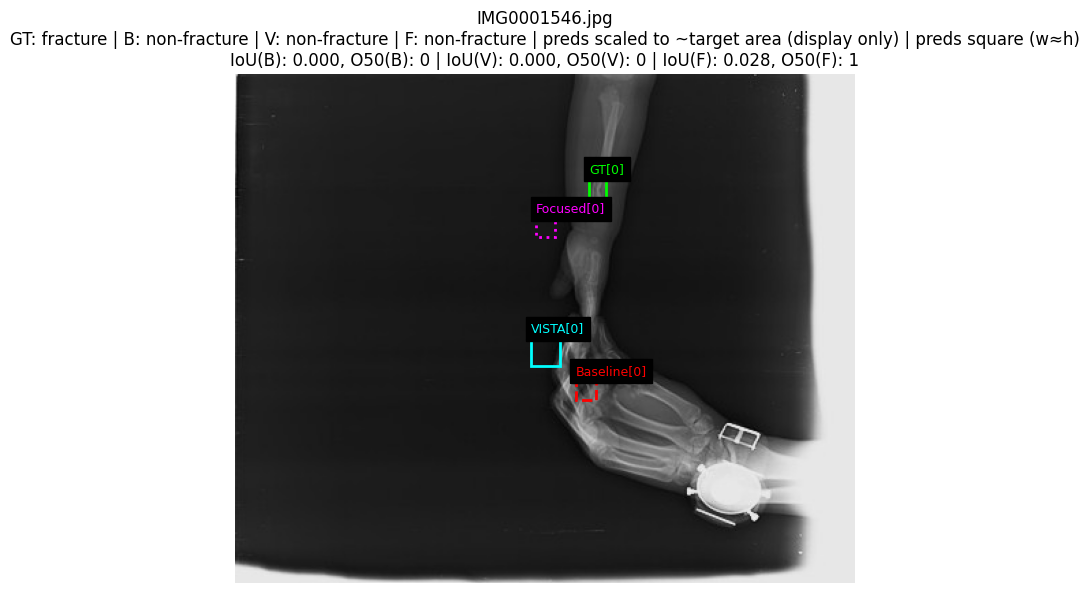

image_id: IMG0002508.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Yes
Focused cls text: Yes
Baseline bbox text: [0.26, 0.69, 0.44, 0.98]
VISTA bbox text: [0.0, 0.1, 0.1, 0.2]
Focused bbox text: [0.3, 0.4, 0.4, 0.5]
GT boxes (VOC raw): [[98.0, 182.0, 114.0, 204.0], [110.0, 185.0, 123.0, 207.0], [273.0, 207.0, 289.0, 222.0], [289.0, 213.0, 303.0, 232.0]]
GT boxes (plot): [[98.0, 182.0, 114.0, 204.0], [110.0, 185.0, 123.0, 207.0], [273.0, 207.0, 289.0, 222.0], [289.0, 213.0, 303.0, 232.0]] placeholder=False
Baseline boxes (raw): [[96.98, 313.26, 164.12, 444.92]]
VISTA boxes (raw): [[0.0, 45.400000000000006, 37.300000000000004, 90.80000000000001]]
Focused boxes (raw): [[111.89999999999999, 181.60000000000002, 149.20000000000002, 227.0]]


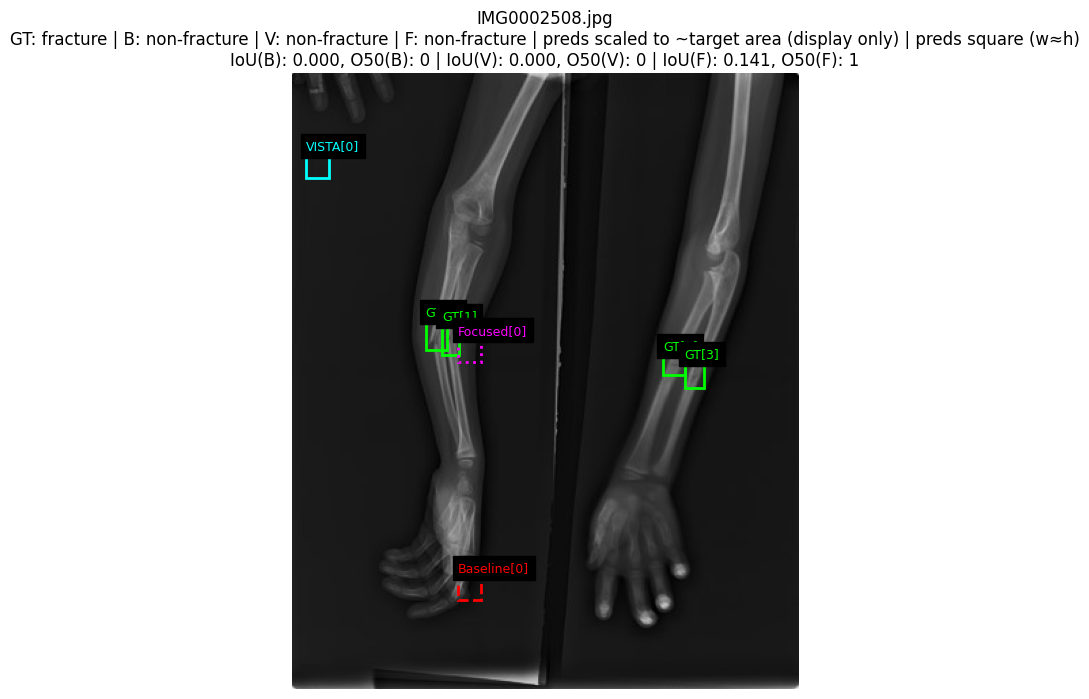

image_id: IMG0002487.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Non-fracture
Focused cls text: Fracture
Baseline bbox text: [0.38, 0.6, 0.58, 0.82]
VISTA bbox text: [0, 1]
---retry_strict---
[0.3, 0.2, 0.7, 0.4]
Focused bbox text: [0.3, 0.1, 0.7, 0.48]
GT boxes (VOC raw): [[240.0, 136.0, 260.0, 149.0]]
GT boxes (plot): [[240.0, 136.0, 260.0, 149.0]] placeholder=False
Baseline boxes (raw): [[172.52, 223.79999999999998, 263.32, 305.85999999999996]]
VISTA boxes (raw): [[136.2, 74.60000000000001, 317.79999999999995, 149.20000000000002]]
Focused boxes (raw): [[136.2, 37.300000000000004, 317.79999999999995, 179.04]]


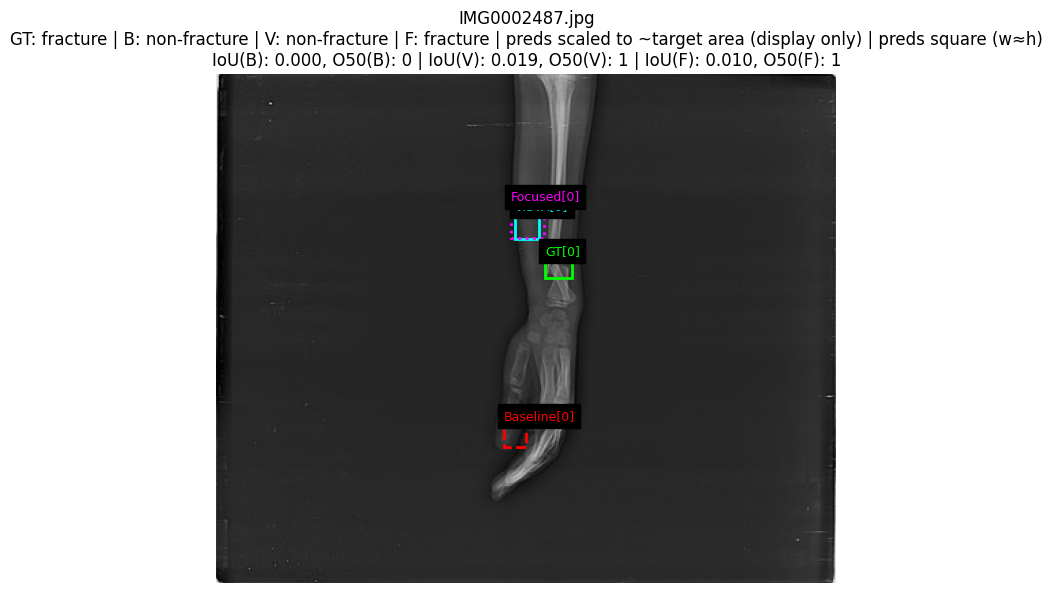

image_id: IMG0003214.jpg
GT label: fracture
Baseline cls text: No
VISTA cls text: Non-fracture
Focused cls text: Non-fracture
Baseline bbox text: [0.18, 0.14, 0.9, 0.42]
VISTA bbox text: [0.0, 0.1, 0.1, 0.2]
Focused bbox text: ONLY [0.2, 0.2, 0.9, 0.4]
GT boxes (VOC raw): [[195.0, 134.0, 207.0, 149.0]]
GT boxes (plot): [[195.0, 134.0, 207.0, 149.0]] placeholder=False
Baseline boxes (raw): [[81.72, 52.220000000000006, 408.6, 156.66]]
VISTA boxes (raw): [[0.0, 37.300000000000004, 45.400000000000006, 74.60000000000001]]
Focused boxes (raw): [[90.80000000000001, 74.60000000000001, 408.6, 149.20000000000002]]


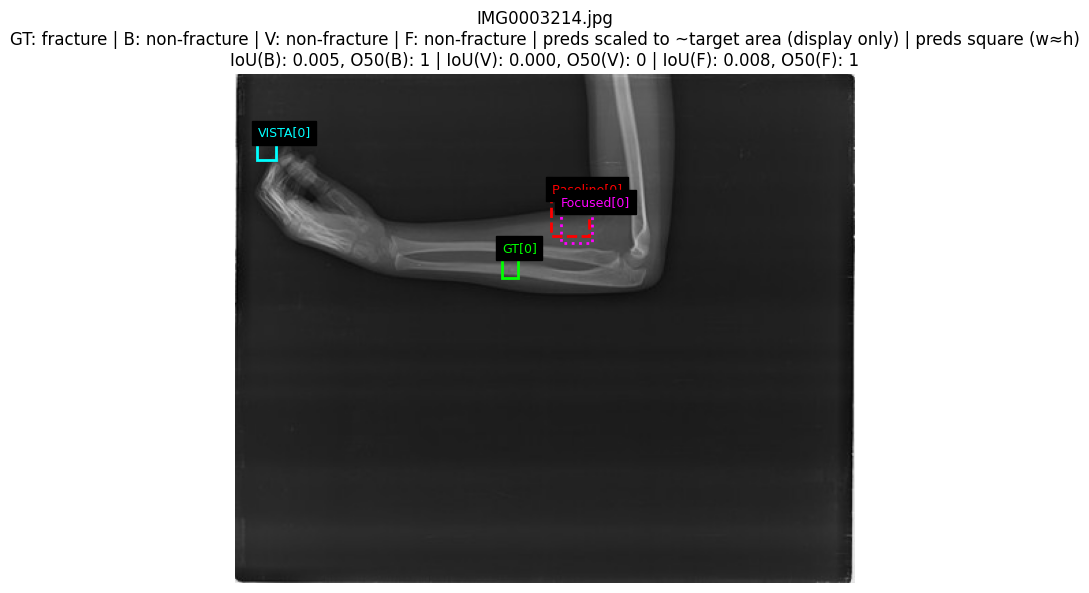

image_id: IMG0002535.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Yes
Focused cls text: Yes
Baseline bbox text: [0.34, 0.69, 0.5, 0.99]
VISTA bbox text: [0.0, 0.1, 0.1, 0.2]
Focused bbox text: ONLY [0.3, 0.4, 0.6, 0.6]
GT boxes (VOC raw): [[177.0, 143.0, 199.0, 249.0]]
GT boxes (plot): [[177.0, 143.0, 199.0, 249.0]] placeholder=False
Baseline boxes (raw): [[126.82000000000001, 313.26, 186.5, 449.46]]
VISTA boxes (raw): [[0.0, 45.400000000000006, 37.300000000000004, 90.80000000000001]]
Focused boxes (raw): [[111.89999999999999, 181.60000000000002, 223.79999999999998, 272.4]]


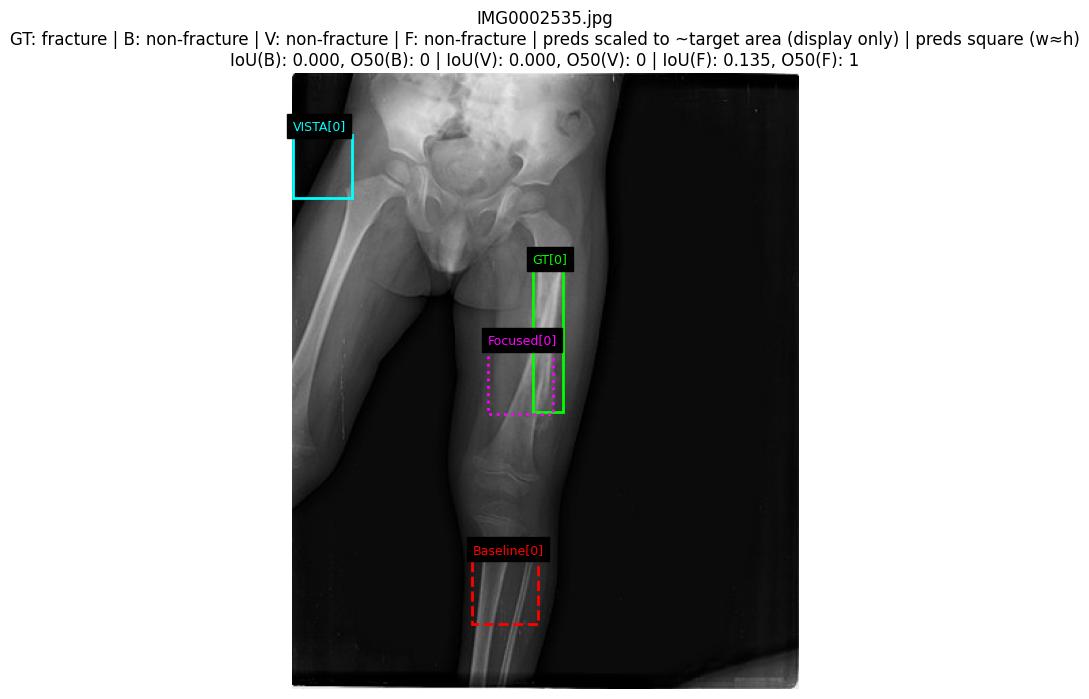

image_id: IMG0002745.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Fracture
Focused cls text: Yes
Baseline bbox text: [0.3, 0.0, 0.68, 0.5]
VISTA bbox text: [0.3, 0.0, 0.7, 0.0]
---retry_strict---
[0.2, 0.0, 0.7, 0.99]
Focused bbox text: ONLY [0.3, 0.6, 0.6, 0.9]
GT boxes (VOC raw): [[156.0, 97.0, 173.0, 117.0], [151.0, 257.0, 178.0, 274.0]]
GT boxes (plot): [[156.0, 97.0, 173.0, 117.0], [151.0, 257.0, 178.0, 274.0]] placeholder=False
Baseline boxes (raw): [[111.89999999999999, 0.0, 253.64000000000001, 227.0]]
VISTA boxes (raw): [[74.60000000000001, 0.0, 261.09999999999997, 449.46]]
Focused boxes (raw): [[111.89999999999999, 272.4, 223.79999999999998, 408.6]]


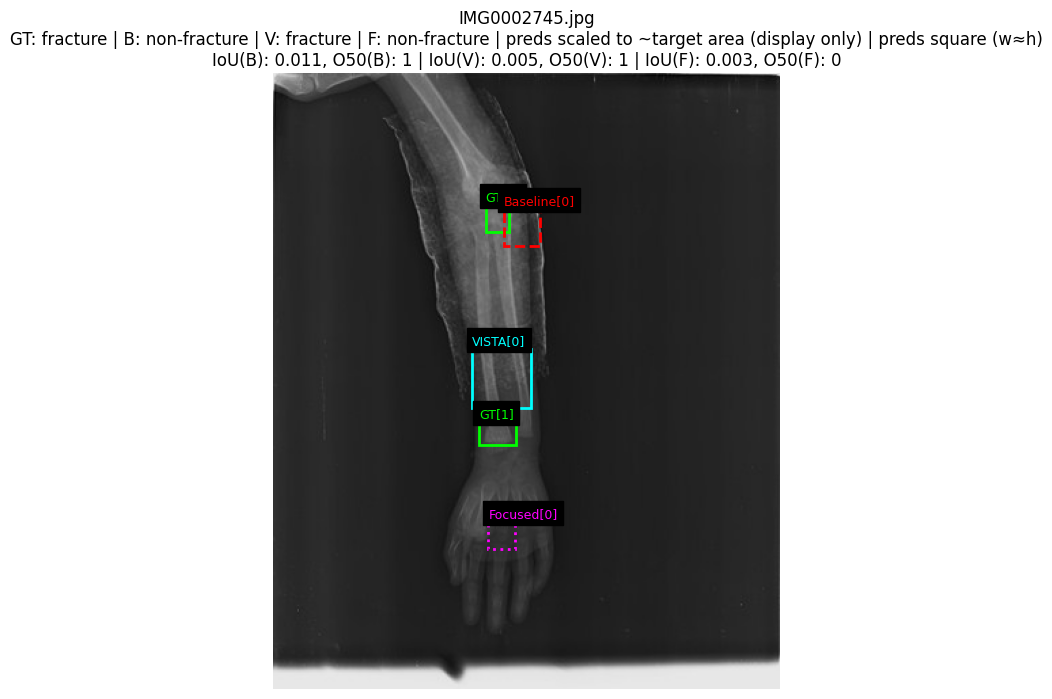

image_id: IMG0002457.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: fracture
Focused cls text: Yes
Baseline bbox text: [0.18, 0.1, 0.44, 0.45]
VISTA bbox text: [0.0, 0.1, 0.1, 0.2]
Focused bbox text: ONLY [0.2, 0.1, 0.4, 0.3]
GT boxes (VOC raw): [[89.0, 170.0, 111.0, 210.0]]
GT boxes (plot): [[89.0, 170.0, 111.0, 210.0]] placeholder=False
Baseline boxes (raw): [[67.14, 45.400000000000006, 164.12, 204.3]]
VISTA boxes (raw): [[0.0, 45.400000000000006, 37.300000000000004, 90.80000000000001]]
Focused boxes (raw): [[74.60000000000001, 45.400000000000006, 149.20000000000002, 136.2]]


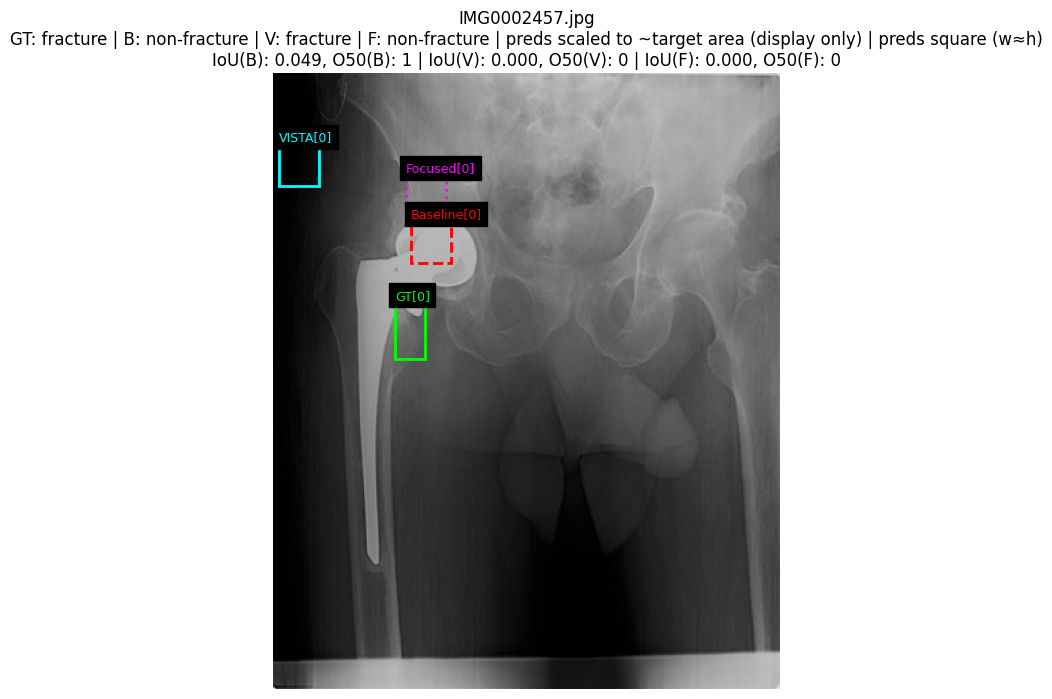

image_id: IMG0003847.jpg
GT label: fracture
Baseline cls text: Yes
VISTA cls text: Fracture
Focused cls text: Fracture
Baseline bbox text: [0.34, 0.14, 0.64, 0.49]
VISTA bbox text: [0.3, 0.3, 0.4, 0.4]
Focused bbox text: [0.3, 0.2, 0.6, 0.4]
GT boxes (VOC raw): [[162.0, 233.0, 192.0, 256.0]]
GT boxes (plot): [[162.0, 233.0, 192.0, 256.0]] placeholder=False
Baseline boxes (raw): [[126.82000000000001, 63.56000000000001, 238.72, 222.46]]
VISTA boxes (raw): [[111.89999999999999, 136.2, 149.20000000000002, 181.60000000000002]]
Focused boxes (raw): [[111.89999999999999, 90.80000000000001, 223.79999999999998, 181.60000000000002]]


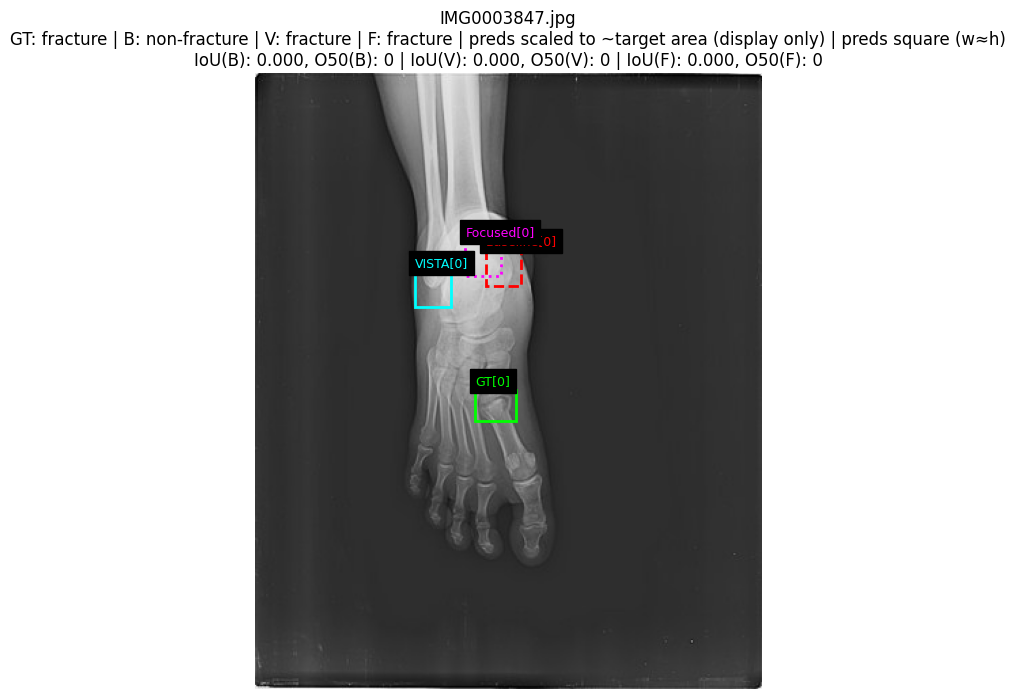

In [14]:
# 9) Visualize FracAtlas images with GT fracture (gt_label=1), with baseline vs VISTA boxes

import ast
import math

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from PIL import Image

# If True, predicted boxes are scaled (same center, ~mean GT area) for display only.
VIZ_SCALE_PRED_TO_GT_MEAN_AREA = True
# If True, predicted boxes are forced to a square with the same area (sqrt(w*h) side).
VIZ_SQUARE_PRED_BOXES = True
# How many GT-fracture images to plot (gt_label == 1).
N_FRACTURE_VIZ = 20

# Jupyter / VS Code: prefer inline figures when an IPython kernel is active
_ipy = globals().get("get_ipython", lambda: None)()
if _ipy is not None:
    _ipy.run_line_magic("matplotlib", "inline")

assert "results_df" in globals(), "Run the evaluation cell first to create results_df."
assert "resolve_image_path" in globals(), "Run dataset/helper cells first."


def _parse_box_list(val):
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return []
    if isinstance(val, list):
        return val
    s = str(val).strip()
    if not s or s == "[]":
        return []
    return ast.literal_eval(s)


def _mean_gt_box_area(gt_boxes):
    areas = []
    for b in gt_boxes:
        if len(b) != 4:
            continue
        x1, y1, x2, y2 = map(float, b)
        areas.append(max(0.0, x2 - x1) * max(0.0, y2 - y1))
    return sum(areas) / len(areas) if areas else None


def _scale_box_to_target_area(box, target_area, W, H):
    x1, y1, x2, y2 = map(float, box)
    w0 = x2 - x1
    h0 = y2 - y1
    if w0 <= 0 or h0 <= 0 or target_area is None or target_area <= 0:
        return [x1, y1, x2, y2]
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    cur = w0 * h0
    s = math.sqrt(target_area / cur)
    s = max(0.15, min(6.0, s))
    nw, nh = w0 * s, h0 * s
    nx1, ny1 = cx - nw / 2.0, cy - nh / 2.0
    nx2, ny2 = cx + nw / 2.0, cy + nh / 2.0
    nx1, ny1 = max(0.0, nx1), max(0.0, ny1)
    nx2, ny2 = min(float(W), nx2), min(float(H), ny2)
    if nx2 <= nx1 or ny2 <= ny1:
        return [x1, y1, x2, y2]
    return [nx1, ny1, nx2, ny2]


def _gt_boxes_for_display(gt_boxes, gt_label, W, H):
    """Non-fractured VOC files often have no <object>; draw full-image reference (not a fracture ROI)."""
    if gt_boxes:
        return gt_boxes, False
    if int(gt_label) == 0:
        return [[0.0, 0.0, float(W), float(H)]], True
    return [], False


def _squareize_box(box, W, H):
    """Same width and height ~ sqrt(original area), same center (display only)."""
    x1, y1, x2, y2 = map(float, box)
    w0 = x2 - x1
    h0 = y2 - y1
    if w0 <= 0 or h0 <= 0:
        return [x1, y1, x2, y2]
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    side = math.sqrt(max(1e-6, w0 * h0))
    nx1, ny1 = cx - side / 2.0, cy - side / 2.0
    nx2, ny2 = cx + side / 2.0, cy + side / 2.0
    nx1, ny1 = max(0.0, nx1), max(0.0, ny1)
    nx2, ny2 = min(float(W), nx2), min(float(H), ny2)
    if nx2 <= nx1 or ny2 <= ny1:
        return [x1, y1, x2, y2]
    return [nx1, ny1, nx2, ny2]


_comp_cols = [
    "variant",
    "image_id",
    "image_path",
    "gt_label",
    "pred_label",
    "gt_boxes",
    "pred_boxes",
    "pred_boxes_norm",
    "classification_text",
    "bbox_text",
    "best_iou",
    "best_gt_overlap",
    "bbox_correct_50",
]
comp = results_df[[c for c in _comp_cols if c in results_df.columns]].copy()

baseline_df = comp[comp["variant"] == "baseline"].copy()
vista_df = comp[comp["variant"] == "vista_model"].copy()
focused_df = (
    comp[comp["variant"] == "vista_focused"].copy()
    if (comp["variant"] == "vista_focused").any()
    else pd.DataFrame()
)

_merge_keys = ["image_id", "gt_label", "image_path"]
merged = baseline_df.merge(
    vista_df,
    on=_merge_keys,
    suffixes=("_baseline", "_vista"),
)
if len(focused_df) > 0:
    f_drop = focused_df.drop(columns=["variant"]).copy()
    _rn = {c: f"{c}_focused" for c in f_drop.columns if c not in _merge_keys}
    merged = merged.merge(f_drop.rename(columns=_rn), on=_merge_keys, how="left")

fixed_cls = merged[
    (merged["pred_label_baseline"] != merged["gt_label"])
    & (merged["pred_label_vista"] == merged["gt_label"])
].copy()

fixed_cls_bbox = fixed_cls[fixed_cls["bbox_correct_50_vista"] == 1].copy()

print(f"Total compared images: {len(merged)}")
print(f"Baseline fail -> VISTA fix (classification): {len(fixed_cls)}")
print(f"Baseline fail -> VISTA fix + VISTA bbox>=50%: {len(fixed_cls_bbox)}")

fracture_merged = merged[merged["gt_label"] == 1].copy()
print(f"Fractured (GT) images in merge: {len(fracture_merged)}")

# Primary: plot samples where ground truth is fracture (VOC fracture ROIs available when annotated).
if len(fracture_merged) > 0:
    pool = fracture_merged.head(N_FRACTURE_VIZ)
    print(f"Plotting {len(pool)} fractured sample(s) (gt_label=1).")
else:
    pool = fracture_merged
    print("No fractured rows in merge; falling back to previous selection logic.")

if len(pool) == 0:
    pool = fixed_cls_bbox if len(fixed_cls_bbox) > 0 else fixed_cls
if len(pool) == 0:
    vista_cls_ok = merged[merged["pred_label_vista"] == merged["gt_label"]].copy()
    if len(vista_cls_ok) > 0:
        print(
            "Note: Using VISTA-correct rows (no GT-fracture rows in merge)."
        )
        pool = vista_cls_ok.head(8)
    elif len(merged) > 0:
        print("Note: Showing first merged rows for debugging.")
        pool = merged.head(8)
    else:
        pool = merged
        print(
            "merged is empty: need baseline + vista_model rows (and optionally vista_focused) "
            "with matching image_id, gt_label, image_path."
        )

if len(pool) == 0:
    print("No rows to visualize.")
else:
    N_SHOW = min(8, len(pool))
    samples = pool.head(N_SHOW)

    def _draw_box(ax, box, color, label, linestyle="-"):
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle(
            (x1, y1),
            w,
            h,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
            linestyle=linestyle,
        )
        ax.add_patch(rect)
        ax.text(x1, max(0, y1 - 4), label, color=color, fontsize=9, backgroundcolor="black")

    for _, r in samples.iterrows():
        img_path = r["image_path"]
        try:
            img = Image.open(img_path).convert("RGB")
        except OSError as e:
            print(f"Skip {img_path}: could not open image ({e})")
            continue
        W, H = img.size

        gt_label = int(r["gt_label"])
        gt_text = "fracture" if gt_label == 1 else "non-fracture"
        b_pred = int(r["pred_label_baseline"])
        v_pred = int(r["pred_label_vista"])
        f_pred = int(r["pred_label_focused"]) if "pred_label_focused" in r.index and pd.notna(r.get("pred_label_focused")) else -1

        b_text = "fracture" if b_pred == 1 else "non-fracture"
        v_text = "fracture" if v_pred == 1 else "non-fracture"
        f_text = "fracture" if f_pred == 1 else "non-fracture" if f_pred >= 0 else "n/a"

        gt_boxes_raw = _parse_box_list(r.get("gt_boxes_baseline"))
        b_boxes = _parse_box_list(r.get("pred_boxes_baseline"))
        v_boxes = _parse_box_list(r.get("pred_boxes_vista"))
        f_boxes = _parse_box_list(r.get("pred_boxes_focused")) if "pred_boxes_focused" in r.index else []

        gt_boxes_plot, gt_is_placeholder = _gt_boxes_for_display(gt_boxes_raw, gt_label, W, H)

        tgt_area = None
        if VIZ_SCALE_PRED_TO_GT_MEAN_AREA:
            if gt_boxes_raw:
                tgt_area = _mean_gt_box_area(gt_boxes_raw)
            elif b_boxes or v_boxes or f_boxes:
                tgt_area = 0.12 * float(W) * float(H)

        if VIZ_SCALE_PRED_TO_GT_MEAN_AREA and tgt_area is not None:
            b_draw = [_scale_box_to_target_area(b, tgt_area, W, H) for b in b_boxes]
            v_draw = [_scale_box_to_target_area(b, tgt_area, W, H) for b in v_boxes]
            f_draw = [_scale_box_to_target_area(b, tgt_area, W, H) for b in f_boxes]
        else:
            b_draw, v_draw, f_draw = list(b_boxes), list(v_boxes), list(f_boxes)

        if VIZ_SQUARE_PRED_BOXES:
            b_draw = [_squareize_box(b, W, H) for b in b_draw]
            v_draw = [_squareize_box(b, W, H) for b in v_draw]
            f_draw = [_squareize_box(b, W, H) for b in f_draw]

        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        ax.imshow(img)
        ax.axis("off")

        for i, box in enumerate(gt_boxes_plot):
            glab = (
                "GT (full image — no fracture ROI in VOC)"
                if gt_is_placeholder and i == 0
                else f"GT[{i}]"
            )
            _draw_box(ax, box, "lime", glab)

        for i, box in enumerate(b_draw):
            _draw_box(ax, box, "red", f"Baseline[{i}]", linestyle="--")

        for i, box in enumerate(v_draw):
            _draw_box(ax, box, "cyan", f"VISTA[{i}]")

        for i, box in enumerate(f_draw):
            _draw_box(ax, box, "magenta", f"Focused[{i}]", linestyle=":")

        scale_note = ""
        if VIZ_SCALE_PRED_TO_GT_MEAN_AREA and tgt_area is not None:
            scale_note = " | preds scaled to ~target area (display only)"
        if VIZ_SQUARE_PRED_BOXES:
            scale_note += " | preds square (w≈h)"
        if gt_is_placeholder:
            scale_note += " | GT box = full image (VOC has no objects)"
        _iou_f = (
            f" | IoU(F): {float(r['best_iou_focused']):.3f}, O50(F): {int(r['bbox_correct_50_focused'])}"
            if "best_iou_focused" in r.index and pd.notna(r.get("best_iou_focused"))
            else ""
        )
        title = (
            f"{r['image_id']}\n"
            f"GT: {gt_text} | B: {b_text} | V: {v_text} | F: {f_text}{scale_note}\n"
            f"IoU(B): {r['best_iou_baseline']:.3f}, O50(B): {int(r['bbox_correct_50_baseline'])} | "
            f"IoU(V): {r['best_iou_vista']:.3f}, O50(V): {int(r['bbox_correct_50_vista'])}{_iou_f}"
        )
        ax.set_title(title)

        print("=" * 100)
        print("image_id:", r["image_id"])
        print("GT label:", gt_text)
        print("Baseline cls text:", r["classification_text_baseline"])
        print("VISTA cls text:", r["classification_text_vista"])
        if "classification_text_focused" in r.index and pd.notna(r.get("classification_text_focused")):
            print("Focused cls text:", r["classification_text_focused"])
        print("Baseline bbox text:", r["bbox_text_baseline"])
        print("VISTA bbox text:", r["bbox_text_vista"])
        if "bbox_text_focused" in r.index and pd.notna(r.get("bbox_text_focused")):
            print("Focused bbox text:", r["bbox_text_focused"])
        print("GT boxes (VOC raw):", gt_boxes_raw)
        print("GT boxes (plot):", gt_boxes_plot, "placeholder=" + str(gt_is_placeholder))
        print("Baseline boxes (raw):", b_boxes)
        print("VISTA boxes (raw):", v_boxes)
        if f_boxes:
            print("Focused boxes (raw):", f_boxes)
        plt.show()